# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
os.chdir('/Users/burkelawlor/Repos/hci-irae')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium
import sopa

from utils.processing import propogate_subset_labels, get_ranked_genes_by_group
from utils.plotting import feature_plots_from_marker_genes, spatial_plot_cell_types_individual, spatial_plot_cell_types_layered, plot_proportions_bar

In [ ]:
pd.set_option('display.width', 1000)

In [3]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load data

In [4]:
adata_rmc = ad.read_h5ad("./data/adata/rmc_annotated_4_epithelial.h5ad")

In [5]:
sample_list = adata_rmc.obs['sample_name'].unique().to_list()
print(sample_list)

nl_samples = ['NS1', 'NS2','NS3','NS4']
rmc_epd_samples = ['EPD1', 'EPD2','EPD3','EPD4','EPD5','EPD6','EPD7']
nl_epd_samples = ['EPD8','EPD9','EPD10']
pnt_samples = ['PNT1','PNT2']

sample_name_to_condition = {}
for s in nl_samples:
    sample_name_to_condition[s] = 'NL'
for s in rmc_epd_samples:
    sample_name_to_condition[s] = 'RMC_EPD'
for s in nl_epd_samples:
    sample_name_to_condition[s] = 'NL_EPD'
for s in pnt_samples:
    sample_name_to_condition[s] = 'PNT'

adata_rmc.obs['sample_set_2'] = adata_rmc.obs['sample_name'].map(sample_name_to_condition)

['PNT1', 'PNT2', 'EPD1', 'EPD2', 'EPD3', 'EPD4', 'EPD5', 'EPD6', 'EPD7', 'NS1', 'NS2', 'NS3', 'NS4', 'EPD8', 'EPD9', 'EPD10']


/var/folders/l8/r_bqmkfd36n6y9mvy600d2580000gn/T/ipykernel_72749/1071766008.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  sample_list = adata_rmc.obs['sample_name'].unique().to_list()


In [6]:
map_to_ct_general = {
    'Sweat duct':'Sweat duct', 
    'CLEC10A+ DCs':'Immune',
    'Macrophages':'Immune',
    'Fibroblasts':'Fibroblasts',
    'CD8+ T cells':'Immune',
    'CD4+ T cells':'Immune',
    'Tregs':'Immune',
    'Plasma cells':'Immune',
    'Vascular ECs':'Endothelial',
    'Mast cells':'Immune', 
    'Sebocytes':'Sebocytes', 
    'Spinous KCs':'Keratinocytes', 
    'Pericytes':'Pericytes', 
    'Innate lymphocytes':'Immune', 
    'Basal KCs':'Keratinocytes', 
    'LAMP3+ DCs':'Immune', 
    'B cells':'Immune', 
    'Plasmacytoid DC':'Immune', 
    'Melanocytes':'Melanocytes', 
    'Langerhans':'Immune', 
    'Lymphatic ECs':'Endothelial', 
    'CLEC9A+ DCs':'Immune', 
    'Neutrophils':'Immune', 
    'Granular KCs':'Keratinocytes', 
    'Unknown/dead':'Unknown/dead'
}

adata_rmc.obs['ct_general'] = adata_rmc.obs['ct_detailed'].map(map_to_ct_general)

# Cleaning up annotations and exploring

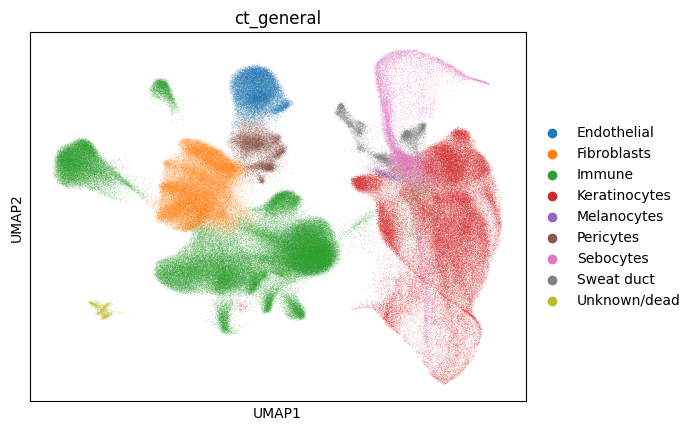

In [7]:
ax = sc.pl.umap(adata_rmc, color=['ct_general'], show=False)
ax.figure.savefig("./figures/umaps/general_annotation_umap.png", bbox_inches="tight")

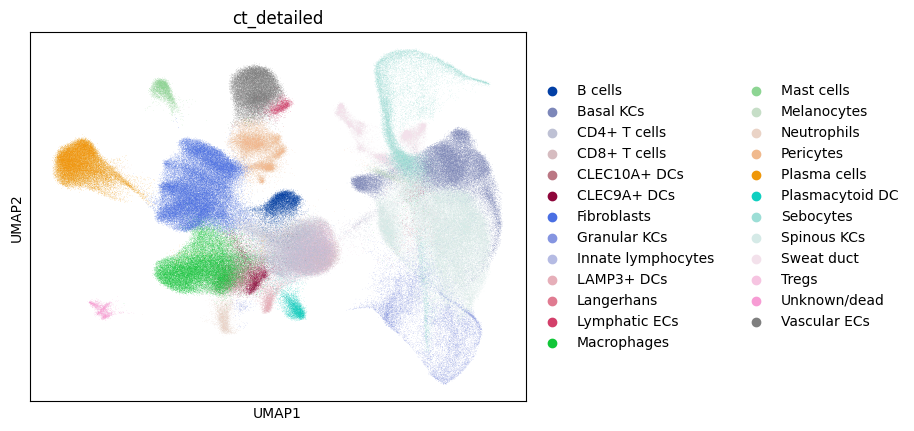

In [8]:
ax = sc.pl.umap(adata_rmc, color=['ct_detailed'], show=False)
ax.figure.savefig("./figures/umaps/detailed_annotation_umap.png", bbox_inches="tight")

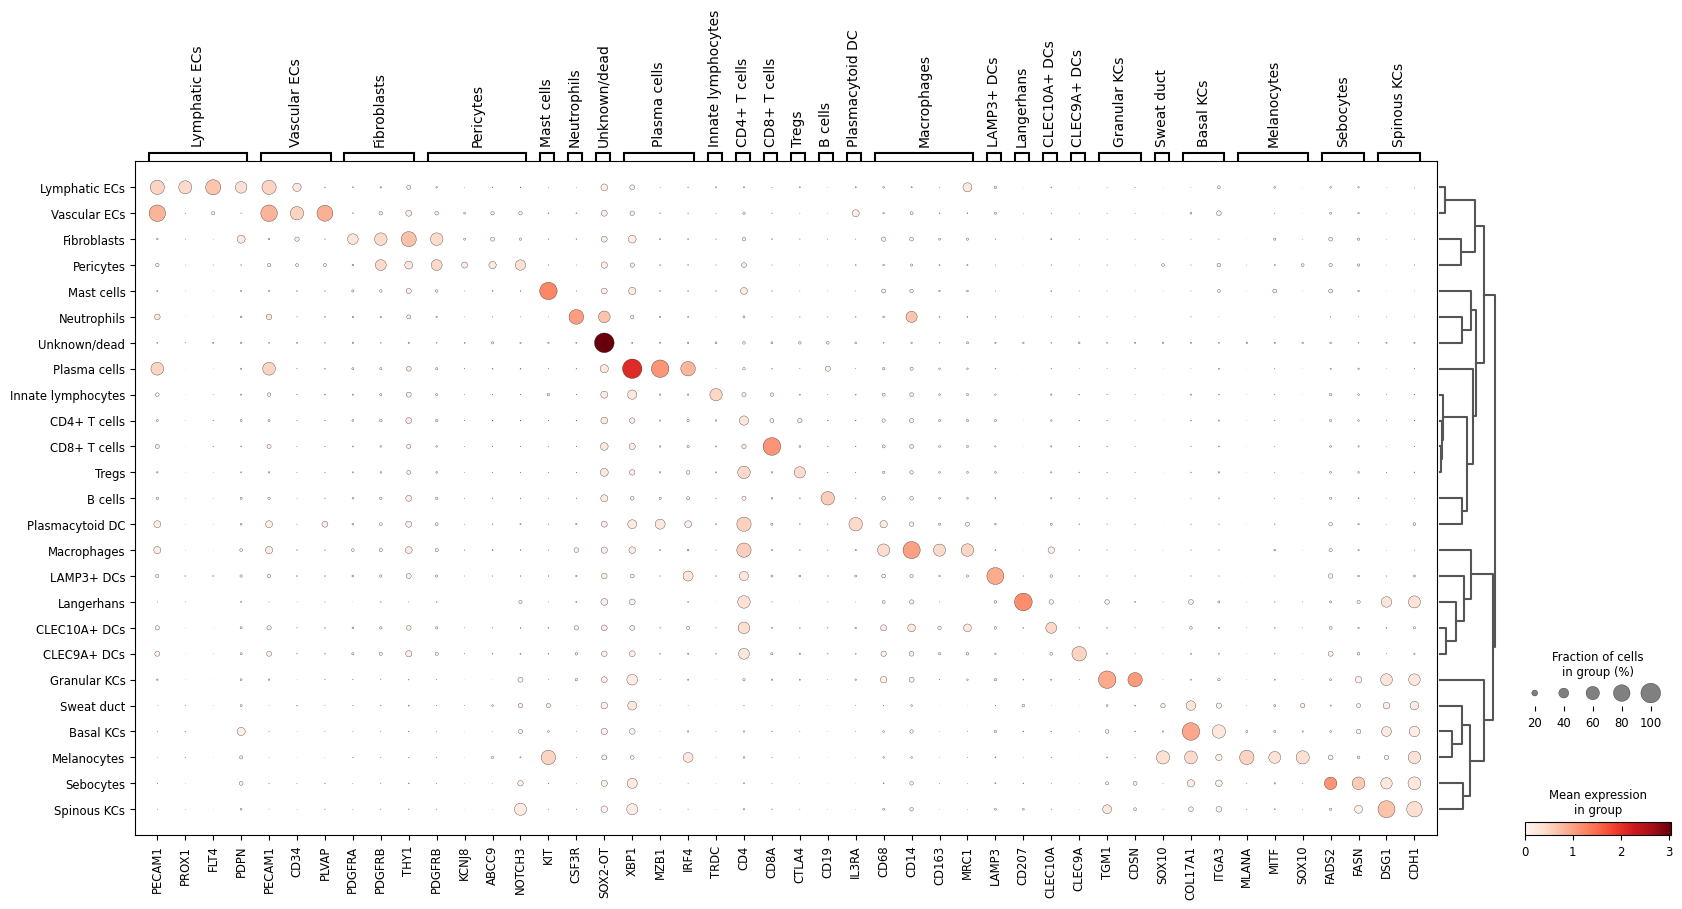

In [9]:
marker_genes_detailed = {
    "Fibroblasts": ["PDGFRA", "PDGFRB",'THY1'],
    'Pericytes': ['PDGFRB','KCNJ8','ABCC9','NOTCH3'],
    "Sweat duct": ["SOX10"],

    # Myeloid
    'Mast cells':['KIT'],
    'Neutrophils':['CSF3R'],
    'Macrophages':['CD68','CD14','CD163','MRC1'],
    'Langerhans':['CD207'],
    'CLEC10A+ DCs':['CLEC10A',],#'CIITA'
    'CLEC9A+ DCs':['CLEC9A',],#'CIITA'
    # 'CXCL9+ DCs':['CXCL9',],#'CIITA'
    'LAMP3+ DCs':['LAMP3',],#'CIITA'
    'Plasmacytoid DC':['IL3RA',],#'CIITA'

    # B cells
    'B cells': ['CD19'],
    'Plasma cells':['XBP1','MZB1','IRF4'],

    # T cells
    'CD8+ T cells':['CD8A'],#'CD3E'
    'CD4+ T cells':['CD4'],#'CD3E'
    'Tregs':['CTLA4'],#'CD3E'
    'Innate lymphocytes':['TRDC'],#'CD3E'
    # 'NK cells':['KLRB1'],#'CD3E'

    # Endothelial
    'Vascular ECs': ['PECAM1','CD34','PLVAP'],
    'Lymphatic ECs': ['PECAM1','PROX1','FLT4','PDPN'],

    # Epithelial
    'Sebocytes':['FADS2','FASN'],
    'Basal KCs':['COL17A1','ITGA3'],#GRN
    'Spinous KCs':['DSG1','CDH1'],#GRN
    'Granular KCs':['TGM1','CDSN'],#GRN
    'Melanocytes': ["MLANA", "MITF", "SOX10"],
    
    
    'Unknown/dead': ['SOX2-OT'],
}

order = marker_genes_detailed.keys() 
# marker_genes_detailed = marker_genes_detailed.pop('Unknown/dead')
ax = sc.pl.dotplot(adata_rmc, marker_genes_detailed, "ct_detailed", dendrogram=True, show=False, categories_order=order)
ax['mainplot_ax'].figure.savefig("./figures/dotplots/detailed_annotation_dotplot.png", bbox_inches="tight")


In [27]:
adata_rmc.write_h5ad("./data/adata/rmc_annotated_5_detailed.h5ad")

# Proportions

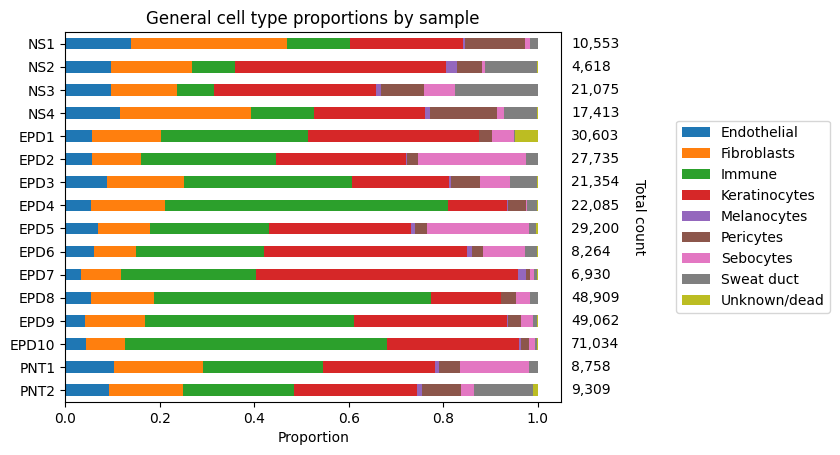

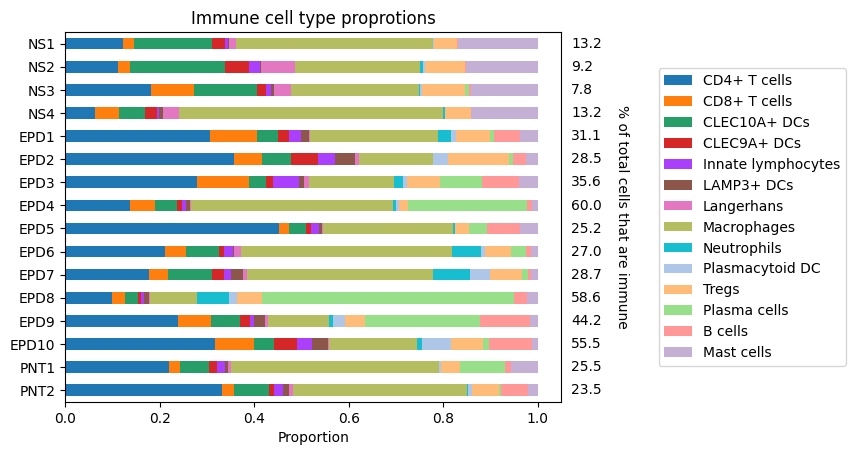

In [119]:
order = ['NS1','NS2','NS3','NS4','EPD1','EPD2','EPD3','EPD4','EPD5','EPD6','EPD7','EPD8','EPD9','EPD10','PNT1','PNT2']

props = plot_proportions_bar(
    adata_rmc, 'sample_name', 'ct_general', order=order, title='General cell type proportions by sample',
    display_totals=True, return_proportions=True,
    save=True
)

pct_immune_labels = ['{:,.1f}'.format(v * 100) for v in props['Immune']]
plot_proportions_bar(
    adata_rmc[adata_rmc.obs['ct_general'] == 'Immune'], 'sample_name', 'ct_immune', order=order, title='Immune cell type proprotions',
    normalize=True, display_totals=pct_immune_labels, display_totals_title=f'% of total cells that are immune',
    save=True
)

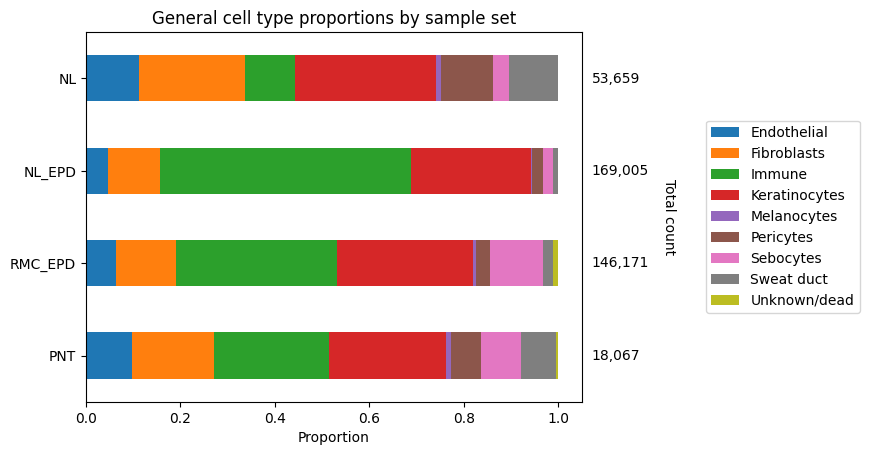

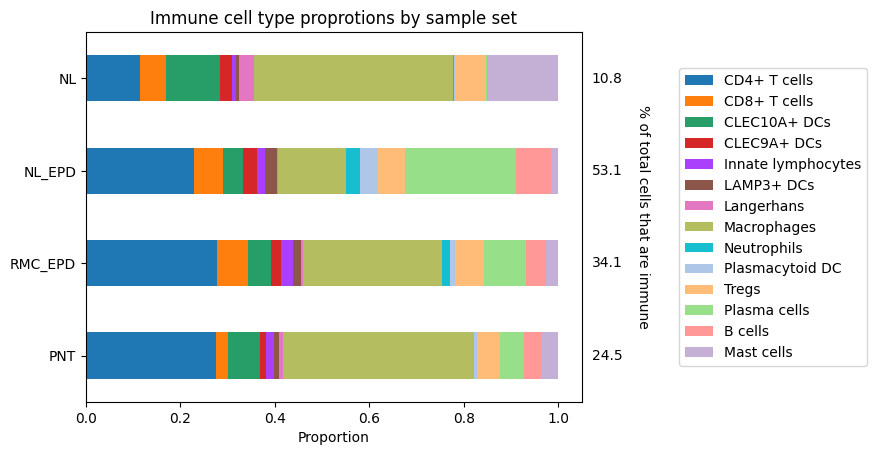

In [118]:
order=['NL','NL_EPD','RMC_EPD','PNT']
props = plot_proportions_bar(
    adata_rmc, 'sample_set_2', 'ct_general', order=order, title='General cell type proportions by sample set',
    display_totals=True, return_proportions=True,
    save=True
)

pct_immune_labels = ['{:,.1f}'.format(v * 100) for v in props['Immune']]
plot_proportions_bar(
    adata_rmc[adata_rmc.obs['ct_general'] == 'Immune'], 'sample_set_2', 'ct_immune', order=order, title='Immune cell type proprotions by sample set',
    normalize=True, display_totals=pct_immune_labels, display_totals_title=f'% of total cells that are immune',
    save=True
)

# Spatial plots

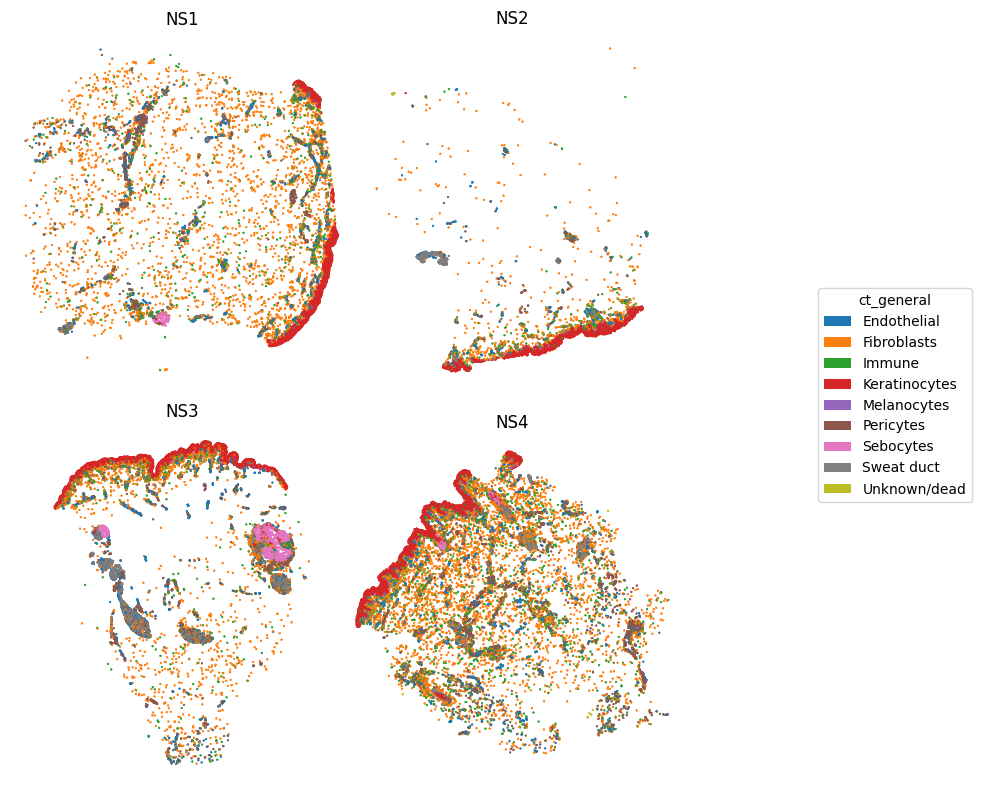

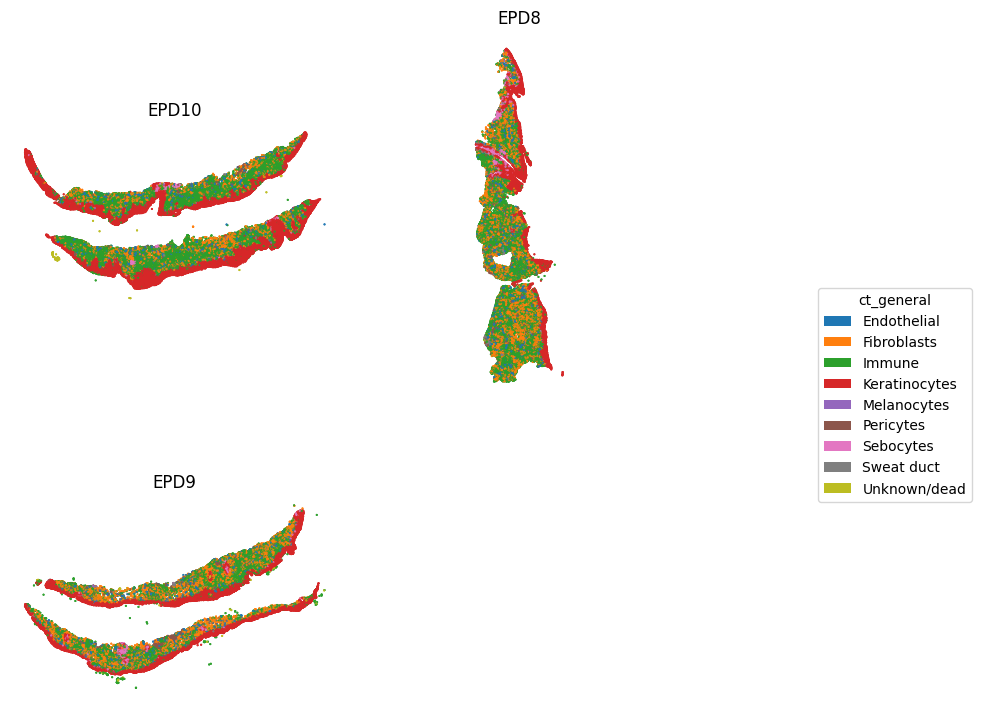

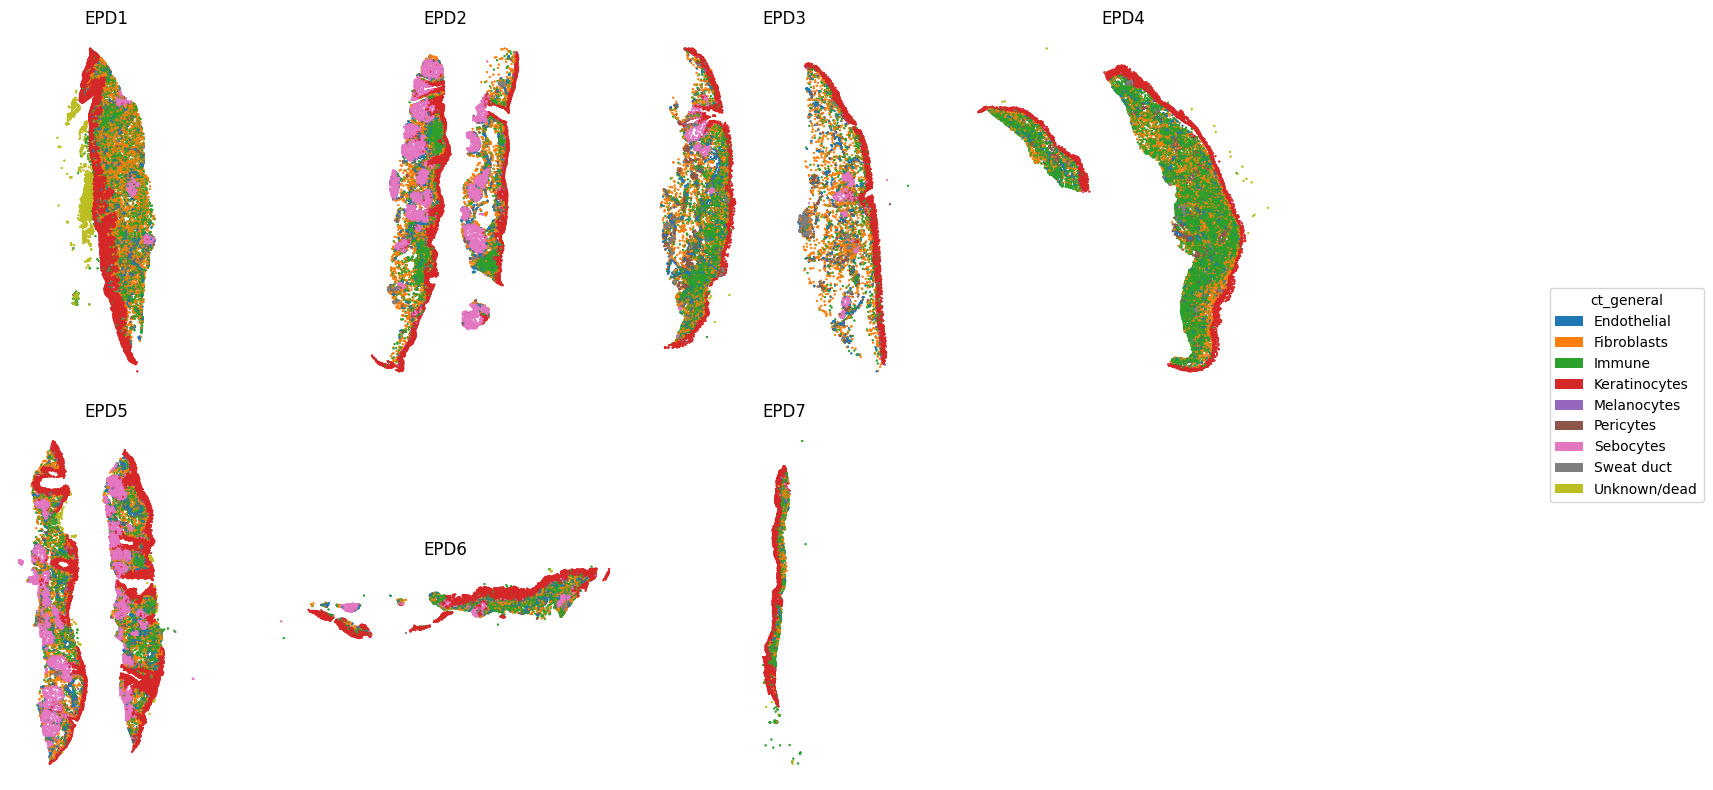

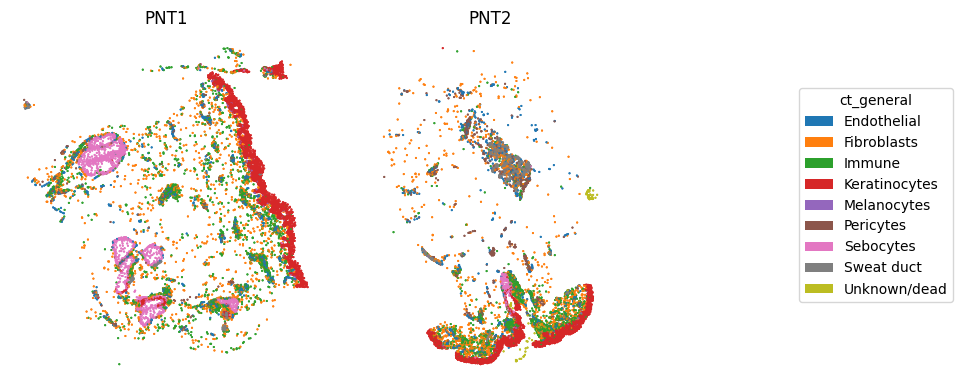

In [19]:
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'NL'], 'ct_general', n_cols=2, save=False)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'NL_EPD'], 'ct_general', n_cols=2, save=False)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'RMC_EPD'], 'ct_general', n_cols=4, save=False)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'PNT'], 'ct_general', n_cols=4, save=False)

# Save to Xenium

In [6]:
# from utils.data_loading import xenium_paths

# for sample, path in xenium_paths.items():
#     adata = adata_rmc[adata_rmc.obs['sample_name'] == sample]
#     adata.obs.drop(columns=['sample_name','sample_set','batch','leiden_25','leiden_20','leiden_03'],inplace=True)
#     sopa.io.explorer.write_cell_categories(path, adata)

In [7]:
# adata_EPD4 = adata_rmc[adata_rmc.obs['sample_name'] == 'EPD4']
# adata_EPD4.obs.drop(columns=['sample_name','sample_set','batch','leiden_25','leiden_20','leiden_10','leiden_03'],inplace=True)

# explorer_path = Path("./data/Xenium/26697R/output-XETG00516__0076678__Region_6__20251017__213834")
# # explorer_path = Path("./data/Xenium/processed/EPD4")
# sopa.io.explorer.write_cell_categories(explorer_path, adata_EPD4)